# Data Understanding
#### Source Data:
The dataset used is data from https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset
<br> The raw data contains 7043 rows (customers) and 21 columns (features). 

#### Data Dictionary :
- customerID - Customer's ID.
- gender - Customer's gender.
- SeniorCitizen - Whether the customer is a senior citizen or not.
- Partner - Whether the customer has a partner or not.
- Dependents - Whether the customer has dependents or not.
- tenure - How long has the customer subscribed in months.
- PhoneService - Whether the customer has a phone service or not.
- MultipleLines - Whether the customer has multiple lines or not.
- InternetService - Customer’s internet service provider status.
- OnlineSecurity - Whether the customer has online security or not.
- OnlineBackup - Whether the customer has online backup or not.
- DeviceProtection - Whether the customer has device protection or not.
- TechSupport - Whether the customer has tech support or not.
- StreamingTV - Whether the customer has streaming TV or not.
- StreamingMovies - Whether the customer has streaming movies or not.
- Contract - The customer's contract term.
- PaperlessBilling - Whether the customer has paperless billing or not.
- PaymentMethod - The customer’s payment method.
- MonthlyCharges - The amount charged to the customer (monthly).
- TotalCharges - The total amount charged to the customer.
- Churn - Whether the customer churned or not churned.

# Import Libraries

In [253]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data

In [254]:
df = pd.read_csv('Telco-Customer-Churn.csv')

In [255]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [256]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [257]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Data Pre-Processing

In [258]:
df = df.drop(columns=['customerID'])

In [259]:
df['TotalCharges'].head()

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: object

In [260]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors="coerce")

In [261]:
df.isna().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [262]:
df = df.dropna()

In [263]:
df.select_dtypes(exclude='object').head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65


In [264]:
new_senior_citizen = []
for i in df['SeniorCitizen']:
    if i == 0:
        new_senior_citizen.append('No')
    elif i == 1:
        new_senior_citizen.append('Yes')
    else:
        new_senior_citizen.append('Unknown')

In [265]:
df['SeniorCitizen'] = new_senior_citizen

In [266]:
payment_methods = []
for i in df['PaymentMethod']:
    if i == 'Electronic check':
        payment_methods.append('EC')
    elif i == 'Mailed check':
        payment_methods.append('MC')
    elif i == 'Bank transfer (automatic)':
        payment_methods.append('BT')
    elif i == 'Credit card (automatic)':
        payment_methods.append('CC')
    else:
        payment_methods.append('Unknown')

In [267]:
df['PaymentMethod'] = payment_methods

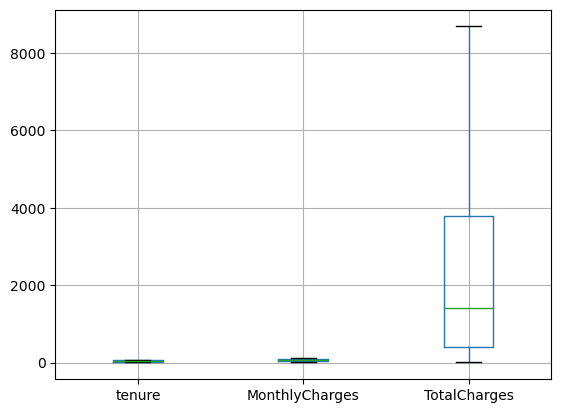

In [268]:
df.select_dtypes(exclude='object').boxplot()
plt.show()

# EDA

In [269]:
df_cat = df.select_dtypes(include='object')
df_num = df.select_dtypes(exclude='object')

In [270]:
df_num['Churn'] = df_cat['Churn']

## Label Distribution

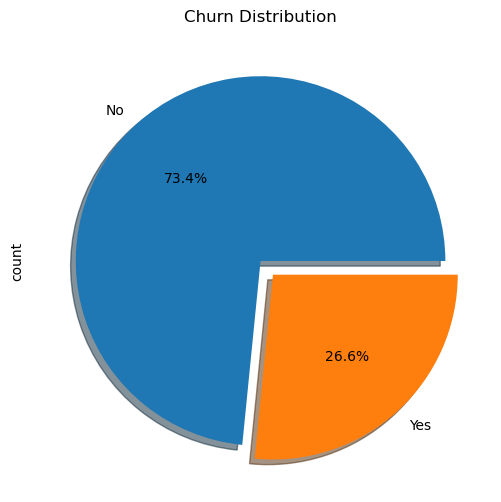

In [271]:
df_num['Churn'].value_counts().plot.pie(
    autopct='%1.1f%%',
    explode=(0, 0.1),
    figsize=(6, 6),    
    shadow=True,
    title='Churn Distribution' 
)
plt.show()

Based on the plot above it shows that 26.6% customers are churn and 73.4% are not churn.

## Numerical Features Analysis

In [272]:
df_num.head()

,tenure,MonthlyCharges,TotalCharges,Churn
0,1,29.85,29.85,No
1,34,56.95,1889.50,No
2,2,53.85,108.15,Yes
3,45,42.30,1840.75,No
4,2,70.70,151.65,Yes


In [273]:
def histplot_and_boxplot(df_num, column, hue):
    
    fig, axes = plt.subplots(1,4, figsize=(20, 4))

    sns.histplot(data=df_num, x=column, ax=axes[0])
    axes[0].set_title(f'{column} Distribution')
    q1 = df_num[column].quantile(0.25)
    q3 = df_num[column].quantile(0.75)
    axes[0].axvline(q1, color='red', linestyle='--')
    axes[0].axvline(q3, color='blue', linestyle='--')
    ymax= axes[0].get_ylim()[1]
    xmax = axes[0].get_xlim()[1]
    axes[0].text(x=q1-(q1*0.05), y=ymax-ymax*0.1, s='Q1', color='red', 
                 va='bottom', ha='right', fontsize=9)
    axes[0].text(x=q3+(q3*0.05), y=ymax-ymax*0.1, s='Q3', color='blue', 
                 va='bottom', ha='left', fontsize=9)
    axes[0].text(x=xmax-xmax*0.35, y=ymax*0.5, s=f'Q1 & Q3\nQ1 = {q1}\nQ3 = {q3}', color='red', 
                 va='bottom', ha='left', fontsize=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='red', boxstyle='round,pad=0.3'))    
    
    sns.histplot(data=df_num, x=column, hue=hue, multiple="stack", stat="count", discrete=False, ax=axes[1])
    axes[1].set_title(f'{column} Distribution')
    q1_churn_yes = df_num[df_num[hue] == 'Yes'][column].quantile(0.25)
    q3_churn_yes = df_num[df_num[hue] == 'Yes'][column].quantile(0.75)
    axes[1].axvline(q1_churn_yes, color='purple', linestyle='--')
    axes[1].axvline(q3_churn_yes, color='blue', linestyle='--')
    ymax_churn_yes= axes[1].get_ylim()[1]
    xmax_churn_yes = axes[1].get_xlim()[1]
    axes[1].text(x=q1_churn_yes-(q1_churn_yes*0.05), y=ymax_churn_yes-ymax_churn_yes*0.1, s='Q1', color='purple', 
                 va='bottom', ha='right', fontsize=9)
    axes[1].text(x=q3_churn_yes+(q3_churn_yes*0.05), y=ymax_churn_yes-ymax_churn_yes*0.1, s='Q3', color='blue', 
                 va='bottom', ha='left', fontsize=9)
    axes[1].text(x=xmax_churn_yes-xmax_churn_yes*0.35, y=ymax_churn_yes*0.5, s=f'Q1 & Q3 Churn = yes\nQ1 = {q1_churn_yes}\nQ3 = {q3_churn_yes}', color='red', 
                 va='bottom', ha='left', fontsize=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='red', boxstyle='round,pad=0.3'))

    sns.boxplot(data=df_num, y=column, width=0.4, ax=axes[2])
    axes[2].set_title(f'{column} Distribution')
    axes[2].axhline(q1, color='red', linestyle='--', label='Q1')
    axes[2].axhline(q3, color='blue', linestyle='--', label='Q3')
    axes[2].text(x=-0.4, y=q1-q1*0.1, s=f'Q1 = {q1:.2f}', color='red', 
                 va='top', ha='left', fontsize=9)
    axes[2].text(x=-0.4, y=q3+q3*0.1, s=f'Q3 = {q3:.2f}', color='blue', 
                 va='bottom', ha='left', fontsize=9)
    axes[2].legend()
    
    sns.boxplot(data=df_num, y=column, hue=hue, gap=0.2, width=0.6, ax=axes[3])
    axes[3].set_title(f'{column} Distribution')

    plt.tight_layout()
    plt.show()

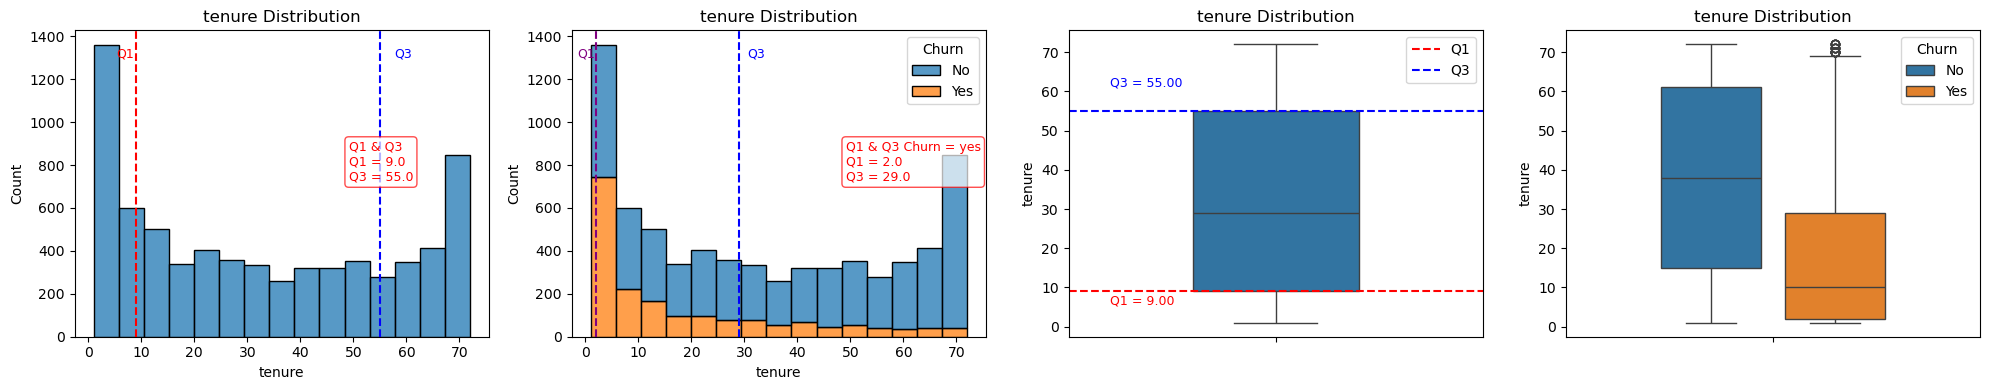

In [274]:
histplot_and_boxplot(df_num, 'tenure', 'Churn')

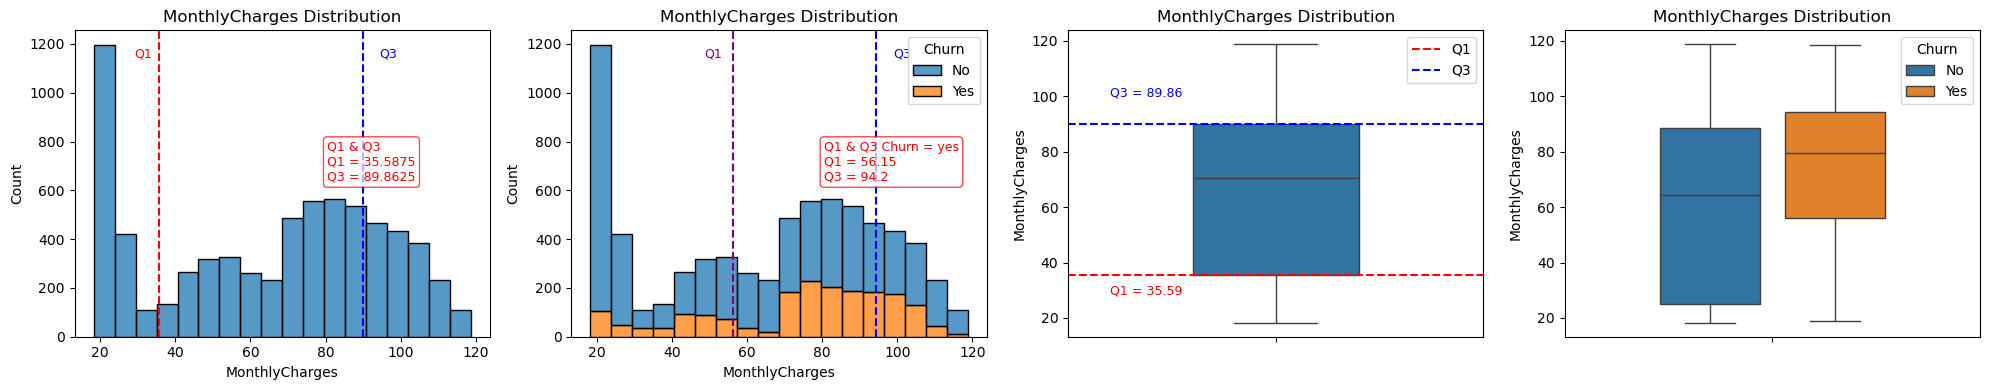

In [275]:
histplot_and_boxplot(df_num, 'MonthlyCharges', 'Churn')

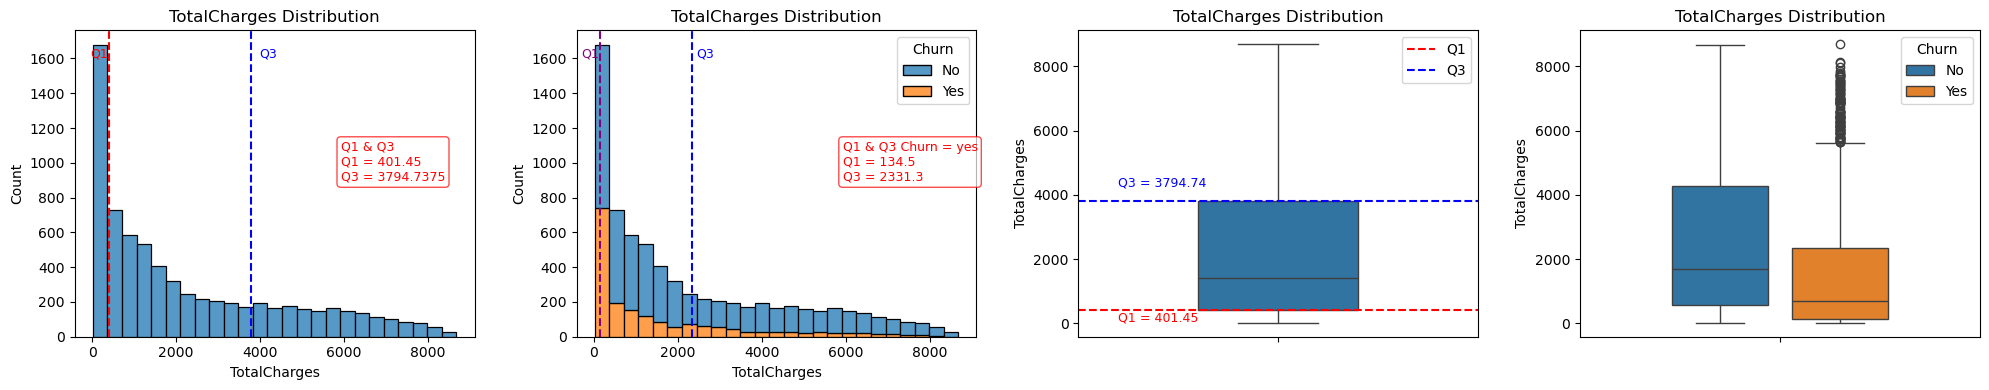

In [276]:
histplot_and_boxplot(df_num, 'TotalCharges', 'Churn')

- Tenure(how long has been subscribe), The majority tenure of customers are in range 9-55 months, and tenure customers who churn are in range 2-29 months.
- MonthlyCharges, The majority monthly charges of customers are in range 35.59-89.86, and monthly charges customers who churn are in range 56.15-94.2.
- TotalCharges, The majority total charges of customers are in range 401-3749, and total charges customers who churn are in range 134-2331.
- All numerical features are not in normal distribution shape, so for correlation analysis and feature scalling we will use spearman and robustscaler.

# Categorical Features Analysis

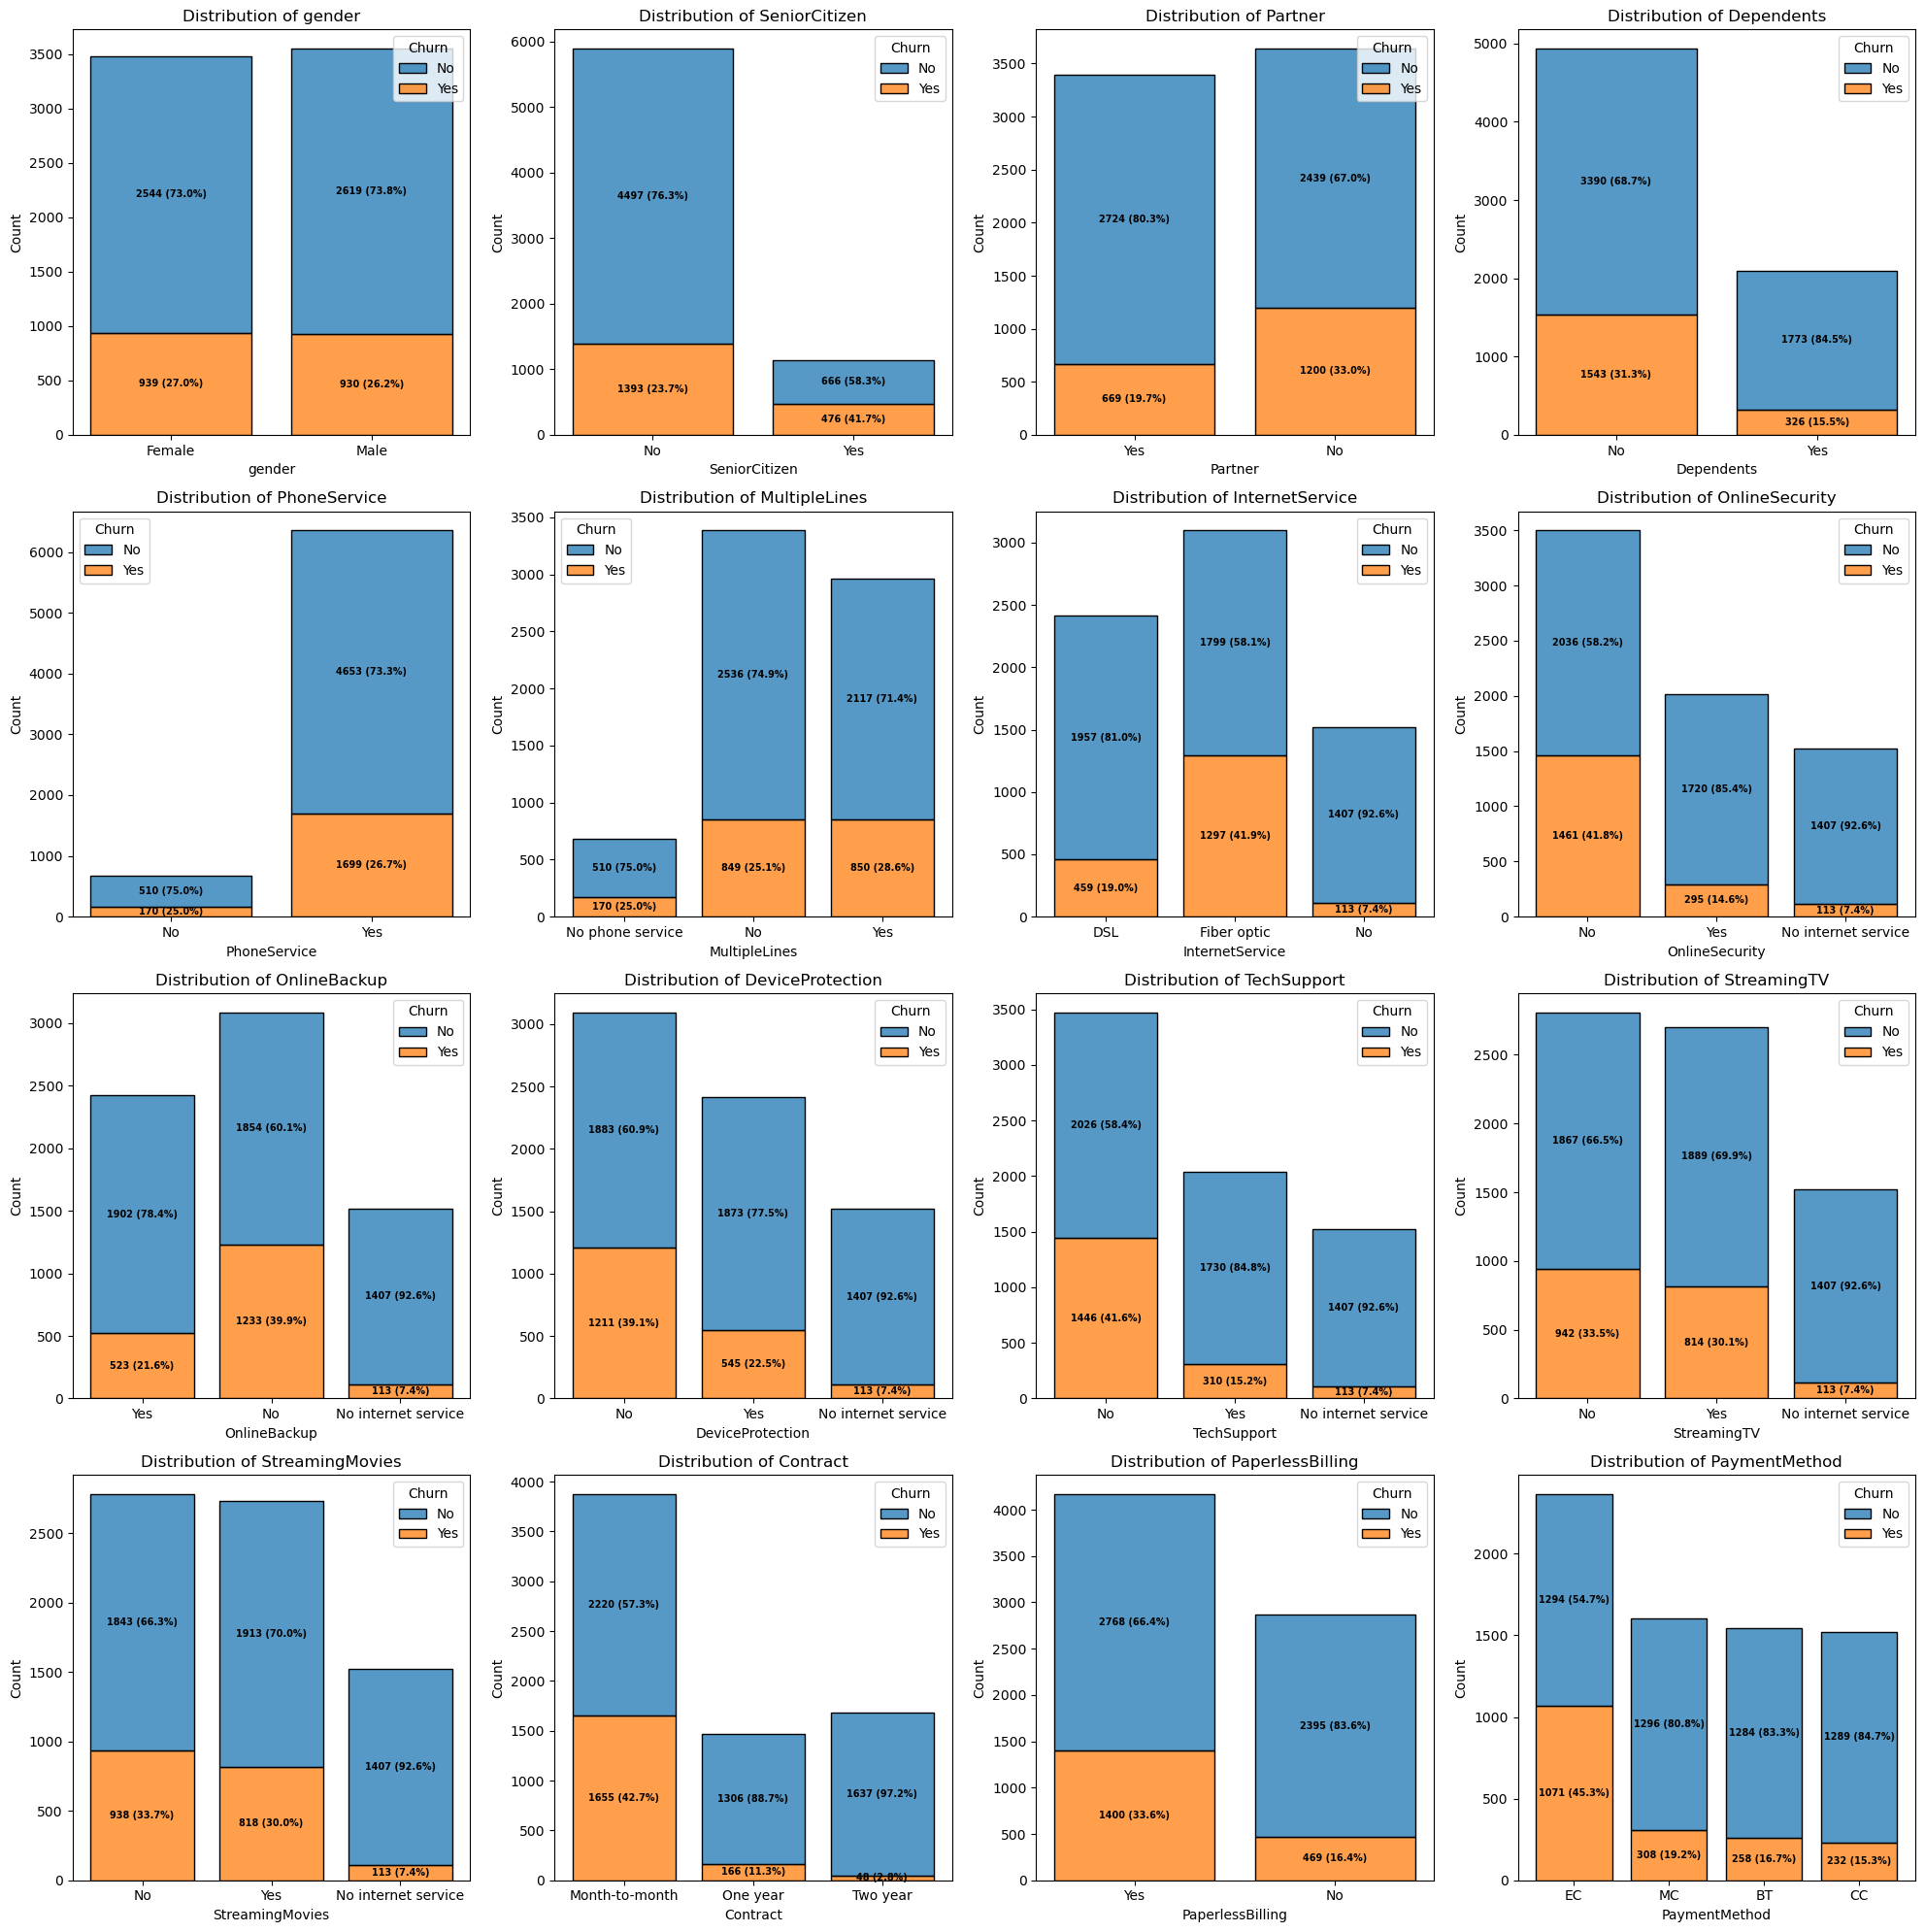

In [277]:
row = 0
col = 0
column_names = df_cat.drop(columns=['Churn']).columns
index_column = 0

def set_number_in_stacked_bar(ax):
    totals = {}
    for p in ax.patches:
        x_pos = p.get_x()
        totals[x_pos] = totals.get(x_pos, 0) + p.get_height()
    
    for p in ax.patches:
        height = p.get_height()
        if height > 0:  # hanya tampilkan kalau ada nilai
            x_pos = p.get_x() + p.get_width()/2
            y_pos = p.get_y() + height/2
            
            total = totals[p.get_x()]
            percent = height / total * 100
            
            ax.text(
                x_pos, y_pos,
                f"{int(height)} ({percent:.1f}%)",  # tampilkan nilai + persentase
                ha="center", va="center", color="black", fontweight="bold", fontsize=7
            )
        
fig, axes= plt.subplots(4, 4, figsize=(20, 20))
for row in range(0, 4):
    for col in range(0, 4):
        if index_column < 16:
            if col < 4:
                sns.histplot(data=df_cat, x=column_names[index_column], hue="Churn", multiple="stack", stat="count", discrete=True, shrink=.8, ax=axes[row][col])
                axes[row][col].set_title(f'Distribution of {column_names[index_column]}')
                set_number_in_stacked_bar(axes[row][col])
                col+=1
                index_column+=1
            else:
                col=0
                sns.histplot(data=df_cat, x=column_names[index_column], hue="Churn", multiple="stack", stat="count", discrete=True, shrink=.8, ax=axes[row][col])
                axes[row][col].set_title(f'Distribution of {column_names[index_column]}')
                set_number_in_stacked_bar(axes[row][col])
                col+=1
                index_column+=1
        else:
            break
    row+=1

plt.tight_layout()
plt.show()

1. Gender:
- Analysis: Gender has almost no impact on churn.
- Data: Females churn at 27.0% and Males at 26.2%. This is a neutral factor.

2. Distribution of SeniorCitizen:
- Analysis: Being a senior citizen is a significant risk factor.
- Data: Seniors churn at a much higher rate (41.7%) compared to non-seniors (23.7%).

3. Distribution of Partner:
- Analysis: Customers without a partner are more unstable.
- Data: Those without a partner have a 33.0% churn rate, while those with a partner drop to 19.7%.

4. Distribution of Dependents:
- Analysis: Having dependents is a strong retention factor.
- Data: Customers with no dependents churn at 31.3%, whereas those with dependents have a low churn rate of 15.5%.

5. Distribution of PhoneService:
- Analysis: Having phone service slightly increases the likelihood of churn, but the difference is small.
- Data: "Yes" churns at 26.7% vs. "No" at 25.0%.

6. Distribution of MultipleLines:
- Analysis: Customers with multiple lines churn slightly more often, likely due to higher bills.
- Data: "Yes" (multiple lines) churns at 28.6%, while single lines ("No") churn at 25.1%.

7. Distribution of InternetService:
- Analysis: This is a critical pain point. Fiber Optic users are extremely unhappy or finding better value elsewhere.
- Data: Fiber optic users have a massive 41.9% churn rate, compared to just 19.0% for DSL users.

8. Distribution of OnlineSecurity:
- Analysis: This is a major retention driver. Customers without security feel less tied to the service.
- Data: Those without Online Security churn at 41.8%; those with it churn at only 14.6%.

9. Distribution of OnlineBackup:
- Analysis: Similar to security, backup services create "stickiness."
- Data: No backup = 39.9% churn. Yes backup = 21.6% churn.

10. Distribution of DeviceProtection:
- Analysis: Protecting the device significantly lowers the chance of leaving.
- Data: No protection = 39.1% churn. Yes protection = 22.5% churn.

11. Distribution of TechSupport:
- Analysis: This is one of the strongest indicators of loyalty. Good support locks customers in.
- Data: Customers without Tech Support churn at 41.6%, while those with it churn at only 15.2%.

12. Distribution of StreamingTV:
- Analysis: Streaming TV is a weak differentiator.
- Data: Those who do not stream TV churn slightly more (33.5%) than those who do (30.1%).

14. Distribution of StreamingMovies:
- Analysis: Like Streaming TV, this has a minimal impact on retention.
- Data: Those who do not stream movies churn at 33.7%, vs. 30.0% for those who do.

15. Distribution of Contract:
- Analysis: This is the single most important predictor in the entire dataset.
- Data: Month-to-month contracts have a huge 42.7% churn rate. Two-year contracts have a tiny 2.8% churn rate.

16. Distribution of PaperlessBilling:
- Analysis: Surprisingly, digital billing correlates with higher churn (perhaps due to ease of switching providers online).
- Data: Yes (Paperless) = 33.6% churn. No (Paper) = 16.4% churn.

17. Distribution of PaymentMethod:
- Analysis: One specific payment method is a major red flag.
- Data: Electronic Check users churn at 45.3%. All other methods (Mailed Check, Bank Transfer, Credit Card) are much more stable, ranging from 15% to 19%.

## Correlation Analysis

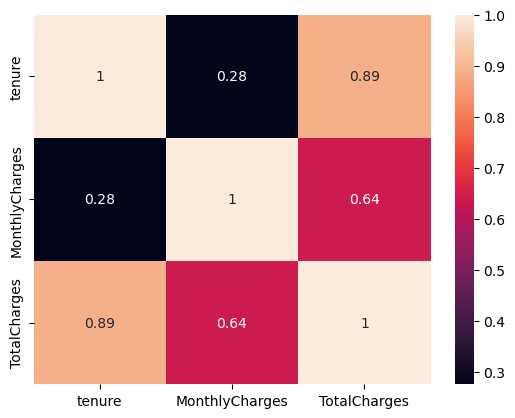

In [278]:
sns.heatmap(df_num.drop(columns=['Churn']).corr(method='spearman'), annot=True)
plt.show()

- Based on the plot above it shows that strong correlations are showed by tenure-totalcharges (0.89) and monthlycharges-totalcharges (0.64).

## Association Analysis

In [279]:
categorical_features = df_cat.columns

In [280]:
categorical_heatmap = pd.DataFrame(
    index=categorical_features,
    columns=categorical_features,
    data=np.zeros((len(categorical_features), len(categorical_features)))
)

In [281]:
from scipy.stats import spearmanr, kruskal, chi2_contingency

In [282]:
for x in categorical_heatmap.columns:
    for y in categorical_heatmap.index:
        confusion_matrix = pd.crosstab(df[x], df[y])
        chi2, _, _, _ = chi2_contingency(confusion_matrix)
        n = confusion_matrix.sum().sum()
        phi2 = chi2 / n
        r, k = confusion_matrix.shape
        result =  np.sqrt(phi2 / min(k - 1, r - 1))
    
        categorical_heatmap.loc[x, y] = result
        categorical_heatmap.loc[y, x] = result

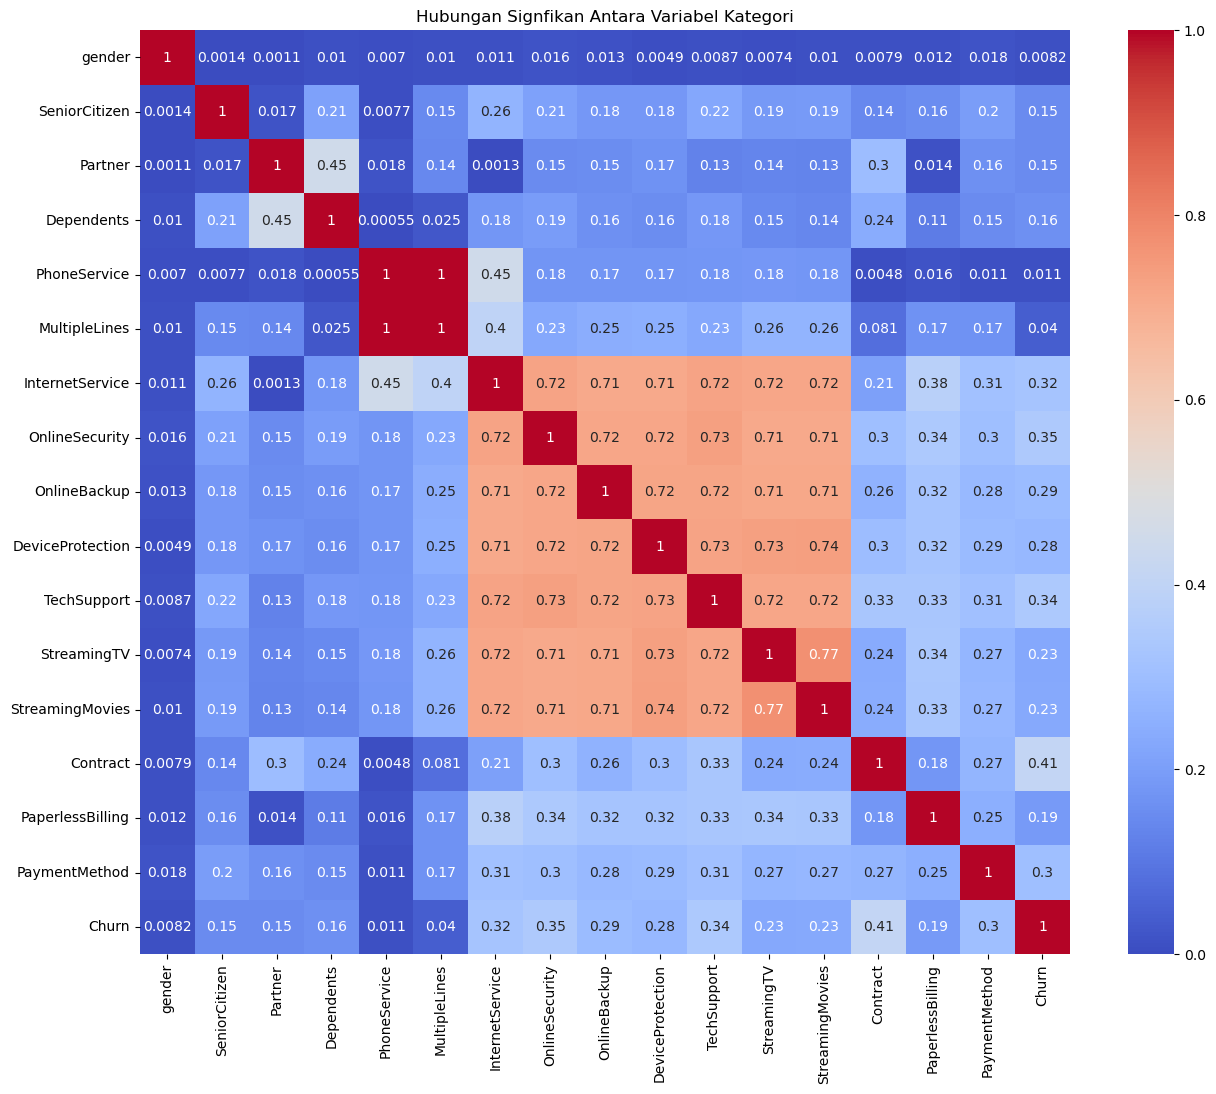

In [283]:
plt.figure(figsize=(15, 12))
sns.heatmap(categorical_heatmap, cmap='coolwarm', annot=True, vmin=0, vmax=1)
plt.title('Hubungan Signfikan Antara Variabel Kategori')
plt.show()

- Based on the plot above it shows that churn has several strong association pairs: contract, onlinesecurity, techsupport and internetservice.
- Besides based on th plot it shows that there some association between independent such as internetservice-streamingmovies, onlinesecurity-streamingmovies, etc.

## Mixed (Correlation and Association Analysis)

In [284]:
def cramers_v(confusion_matrix):
    chi2, _, _, _ = chi2_contingency(confusion_matrix)
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

def kruskal_correlation(cat, num):
    """
    Menggunakan uji Kruskal-Wallis untuk menghitung kekuatan hubungan kategori vs numerik.
    Dikonversi ke nilai korelasi pseudo dengan normalisasi.
    """
    groups = [num[cat == val] for val in np.unique(cat)]
    if len(groups) < 2:
        return np.nan
    try:
        stat, _ = kruskal(*groups)
        # Normalisasi agar berada dalam rentang [0, 1]
        n = len(num)
        return min(stat / (n + 1e-10), 1.0)
    except:
        return np.nan

def mixed_correlation(df):
    cols = df.columns
    corr_matrix = pd.DataFrame(index=cols, columns=cols)

    for col1 in cols:
        for col2 in cols:
            if df[col1].dtype == 'object' or df[col1].dtype.name == 'category':
                if df[col2].dtype == 'object' or df[col2].dtype.name == 'category':
                    conf_matrix = pd.crosstab(df[col1], df[col2])
                    corr = cramers_v(conf_matrix)
                else:
                    corr = kruskal_correlation(df[col1], df[col2])
            else:
                if df[col2].dtype == 'object' or df[col2].dtype.name == 'category':
                    corr = kruskal_correlation(df[col2], df[col1])
                else:
                    corr, _ = spearmanr(df[col1], df[col2])
            corr_matrix.loc[col1, col2] = corr

    return corr_matrix.astype(float)

In [285]:
corr = mixed_correlation(df)

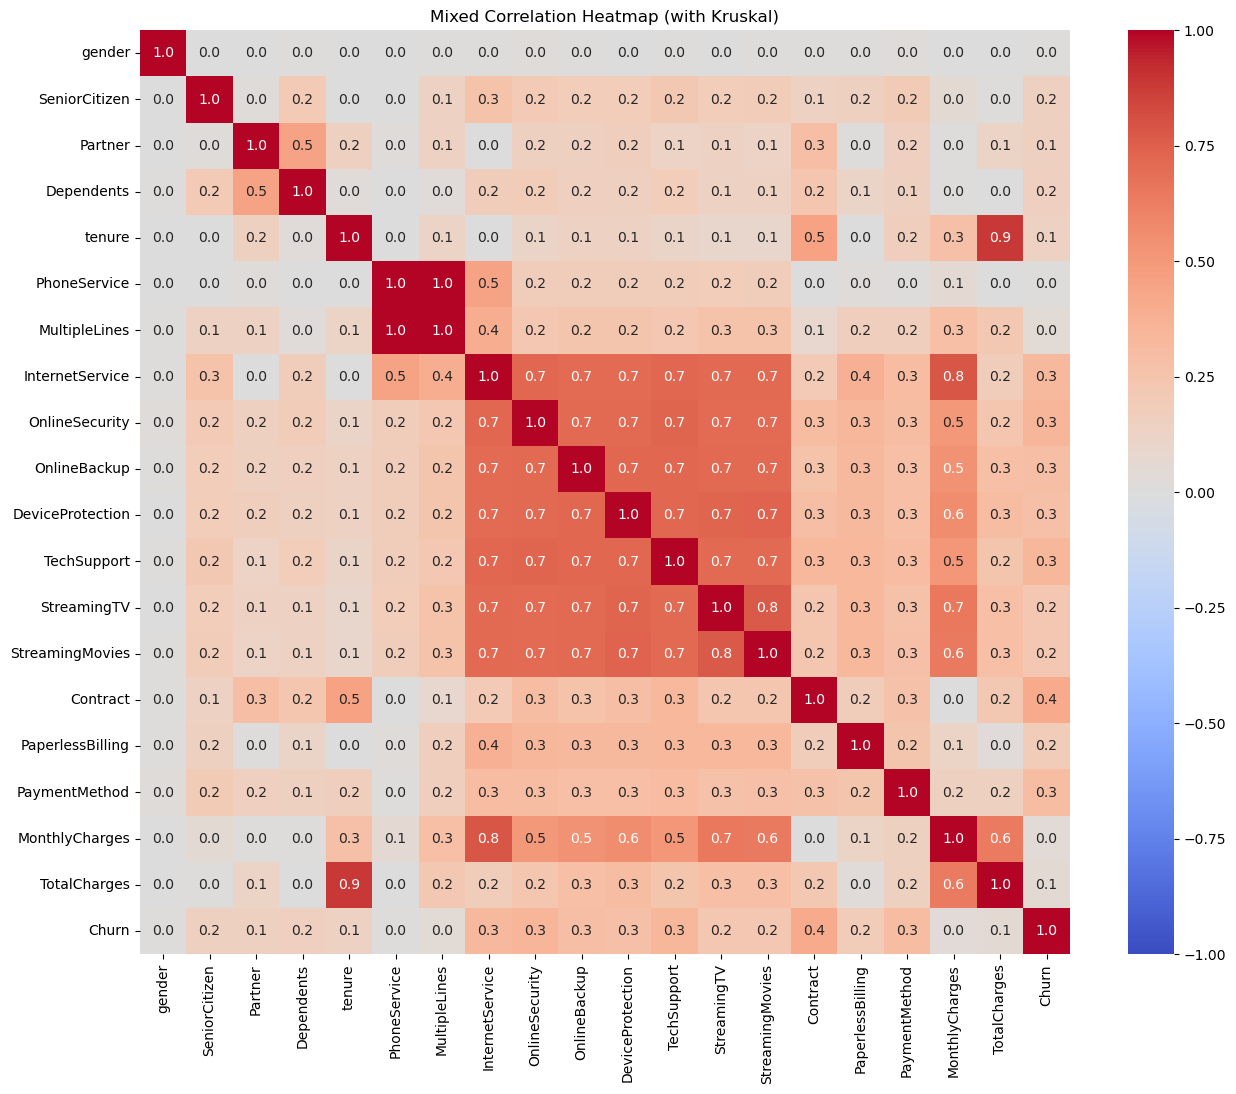

In [286]:
plt.figure(figsize=(15, 12))
sns.heatmap(corr,  vmin=-1, vmax=1, annot=True, fmt=".1f", cmap='coolwarm')
plt.title('Mixed Correlation Heatmap (with Kruskal)')
plt.show()

- Based on the plot above it shows that churn has several strong association pairs: contract, onlinesecurity, techsupport and internetservice.

# Feature Engineering

In [287]:
df_num = df_num.drop(columns=['Churn'])

## Feature Encoding

In [288]:
df_cat = pd.get_dummies(df_cat, columns=['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn'], drop_first=True)

In [289]:
df_cat = pd.get_dummies(df_cat, columns=['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod'])

## Train Test Split

In [290]:
df = df_num.copy()

In [291]:
df[df_cat.columns] = df_cat

In [292]:
df.head()

,tenure,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,PaperlessBilling_Yes,Churn_Yes,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_BT,PaymentMethod_CC,PaymentMethod_EC,PaymentMethod_MC
0,1,29.85,29.85,False,False,True,False,False,True,False,...,True,False,False,True,False,False,False,False,True,False
1,34,56.95,1889.50,True,False,False,False,True,False,False,...,True,False,False,False,True,False,False,False,False,True
2,2,53.85,108.15,True,False,False,False,True,True,True,...,True,False,False,True,False,False,False,False,False,True
3,45,42.30,1840.75,True,False,False,False,False,False,False,...,True,False,False,False,True,False,True,False,False,False
4,2,70.70,151.65,False,False,False,False,True,True,True,...,True,False,False,True,False,False,False,False,True,False


In [293]:
X = df.drop(columns=['Churn_Yes'])
y = df['Churn_Yes']

In [294]:
from sklearn.model_selection import train_test_split

In [295]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

## Feature Scalling

In [296]:
from sklearn.preprocessing import RobustScaler

In [297]:
scaler = RobustScaler()

In [298]:
scaler.fit(X_train[df_num.columns])

RobustScaler()

In [299]:
X_train[df_num.columns] = scaler.transform(X_train[df_num.columns])

In [300]:
X_test[df_num.columns] = scaler.transform(X_test[df_num.columns])

## Feature Importance

In [301]:
from sklearn.ensemble import ExtraTreesClassifier

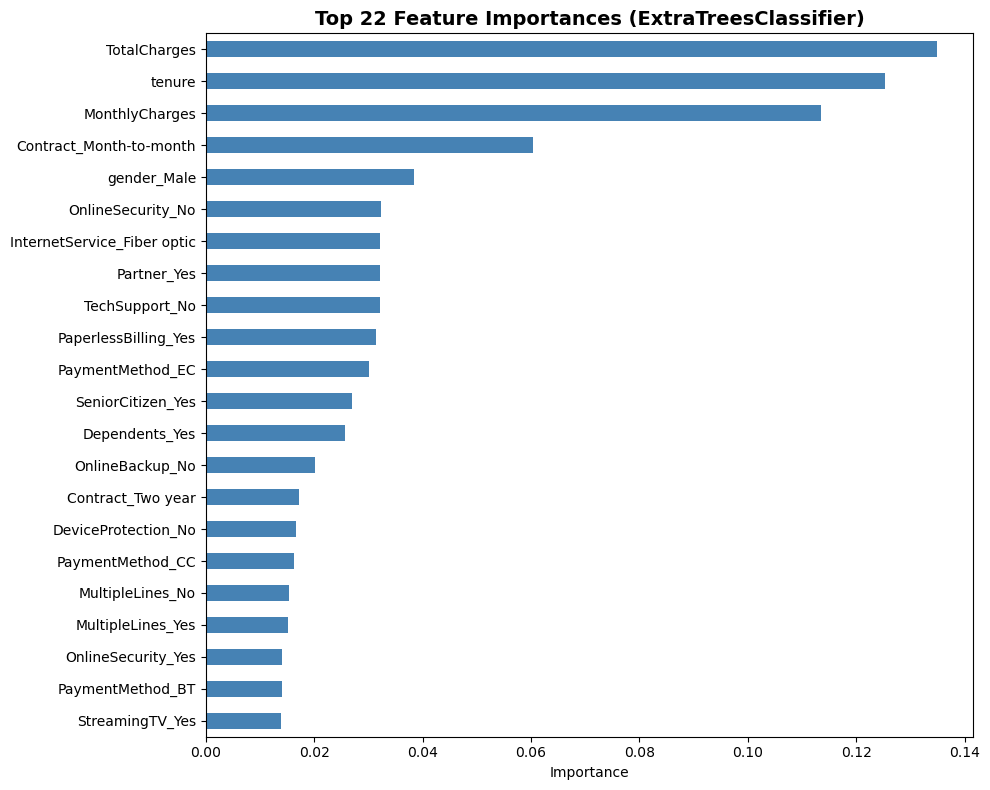

Selected 22 features contributing to 85% cumulative importance.
Top 10 selected features:
   1. TotalCharges
   2. tenure
   3. MonthlyCharges
   4. Contract_Month-to-month
   5. gender_Male
   6. OnlineSecurity_No
   7. InternetService_Fiber optic
   8. Partner_Yes
   9. TechSupport_No
  10. PaperlessBilling_Yes


In [302]:
feature_importance = ExtraTreesClassifier()
feature_importance.fit(X_train, y_train)

importances = pd.Series(feature_importance.feature_importances_,
                         index=X_train.columns).sort_values(ascending=False)

cumulative_imp = importances.cumsum() / importances.sum()
n_selected = (cumulative_imp <= 0.85).sum() + 1   # +1 to include the feature that crosses 85%
n_selected = max(n_selected, 10)  # ensure at least 10 features

fig, ax = plt.subplots(figsize=(10, 8))
importances.head(n_selected).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title(f'Top {n_selected} Feature Importances (ExtraTreesClassifier)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

selected_features = importances.head(n_selected).index.tolist()
print(f'Selected {n_selected} features contributing to 85% cumulative importance.')
print(f'Top 10 selected features:')
for i, feat in enumerate(selected_features[:10], 1):
    print(f'  {i:>2}. {feat}')


In [303]:
X_train_sel = X_train[selected_features]

In [304]:
X_test_sel = X_test[selected_features]

# Modelling

In [305]:
from sklearn.ensemble import RandomForestClassifier

## Random Forest

In [355]:
RF = RandomForestClassifier(class_weight='balanced', ccp_alpha=0.01, oob_score=True, random_state=42)

In [307]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

In [361]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, accuracy_score
import numpy as np

def bias_variance_analysis(model, X_train, y_train, cv=5, model_name="Model"):
    """
    Menghitung Bias dan Variance menggunakan K-Fold Cross-Validation
    
    Bias: Error pada training set (underfitting)
    Variance: Perbedaan error antar fold (overfitting)
    """
    kfold = KFold(n_splits=cv, shuffle=True, random_state=42)
    
    train_scores = []
    val_scores = []
    train_errors = []
    val_errors = []
    train_variances = []
    val_variances = []
    
    for train_idx, test_idx in kfold.split(X_train):
        X_tr, X_te = X_train.iloc[train_idx], X_train.iloc[test_idx]
        y_tr, y_te = y_train.iloc[train_idx], y_train.iloc[test_idx]
        
        # Train model
        model.fit(X_tr, y_tr)
        
        # Predictions
        y_train_pred = model.predict(X_tr)
        y_val_pred = model.predict(X_te)
        
        # Calculate errors
        score_train = accuracy_score(y_tr, y_train_pred)
        score_val = accuracy_score(y_te, y_val_pred)
        train_error = 1 - score_train
        val_error = 1 - score_val
        train_variance = y_train_pred.var()
        val_variance = y_val_pred.var()
        
        train_scores.append(score_train)
        val_scores.append(score_val)
        train_errors.append(train_error)
        val_errors.append(val_error)
        train_variances.append(train_variance)
        val_variances.append(val_variance)
        
    
    train_scores = np.array(train_scores) 
    val_scores = np.array(val_scores)
    train_errors = np.array(train_errors)
    val_errors = np.array(val_errors)
    train_variances = np.array(train_variances)
    val_variances = np.array(val_variances)
    
    # Calculate Bias and Variance
    
    
    return {
        'model':model,
        'train_scores': train_scores,
        'val_scores': val_scores,
        'train_bias': train_errors,
        'val_bias': val_errors,
        'train_variance': train_variances,
        'val_variance': val_variances,
        'avg_train_variance': train_variances.mean(),
        'avg_val_variance': val_variances.mean(),
        'avg_train_bias': train_errors.mean(),
        'avg_val_bias': val_errors.mean()
    }

In [362]:
rf_analysis = bias_variance_analysis(RF, X_train_sel, y_train, cv=5, model_name='Random Forest')

In [363]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_bias_variance_from_analysis(result, figsize=(14,5), save_path=None, show=True):
    """
    Plot hasil bias-variance berdasarkan dict keluaran dari fungsi Anda.
    Memakai keys yang ada: 'avg_train_bias'/'avg_test_bias', 'train_variance', 'test_variance'.
    """
    train_var_arr = np.asarray(result.get('train_variance', []))
    val_var_arr  = np.asarray(result.get('val_variance',  []))
    train_bias_arr  = np.asarray(result.get('train_bias',  []))
    val_bias_arr  = np.asarray(result.get('val_bias',  []))
    avg_train_score = result.get('train_scores', np.nan).mean()
    avg_val_score = result.get('val_scores', np.nan).mean()
    avg_train_bias = result.get('avg_train_bias', np.nan)
    avg_val_bias = result.get('avg_val_bias', np.nan)
    avg_train_var = result.get('avg_train_variance', np.nan)
    avg_val_var = result.get('avg_val_variance', np.nan)

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    axes[0].plot(train_var_arr, label='Train Variance', marker='o')
    axes[0].plot(val_var_arr, label='Validation Variance', marker='o')
    axes[0].set_title('Variance Across Folds')
    axes[0].set_xlabel('Fold')
    axes[0].set_ylabel('Variance')  
    axes[0].legend(loc="upper right")
    axes[0].grid()

    axes[1].plot(train_bias_arr, label='Train Bias', marker='o')
    axes[1].plot(val_bias_arr, label='Validation Bias', marker='o')
    axes[1].set_title('Bias Across Folds')  
    axes[1].set_xlabel('Fold')
    axes[1].set_ylabel('Bias')
    axes[1].legend(loc="upper right")
    axes[1].grid()

    plt.show()

    print(f"Average Train Bias: {avg_train_bias:.4f}")
    print(f"Average Validation Bias: {avg_val_bias:.4f}")
    print(f"Average Train Variance: {avg_train_var:.4f}")
    print(f"Average Validation Variance: {avg_val_var:.4f}")
    print(f"Average Train Score: {avg_train_score:.4f}")
    print(f"Average Validation Score: {avg_val_score:.4f}")

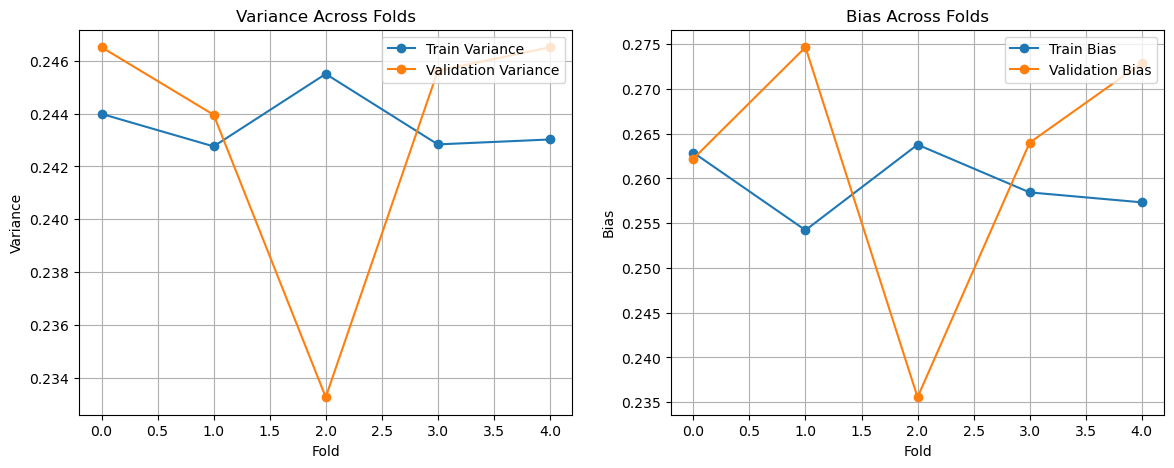

Average Train Bias: 0.2593
Average Validation Bias: 0.2619
Average Train Variance: 0.2436
Average Validation Variance: 0.2432
Average Train Score: 0.7407
Average Validation Score: 0.7381


In [364]:
plot_bias_variance_from_analysis(rf_analysis)

In [312]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title('Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    


    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    auc_score_rf = roc_auc_score(y_test, y_pred)
    axes[1].plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {auc_score_rf:.2f})')
    axes[1].plot([0, 1], [0, 1], color="navy", linestyle="--")  # diagonal line
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('Receiver Operating Characteristic (ROC)')
    axes[1].legend(loc="lower right")
    axes[1].grid()
    plt.show()

    print("Classification Report:")
    print(classification_report(y_test, y_pred))

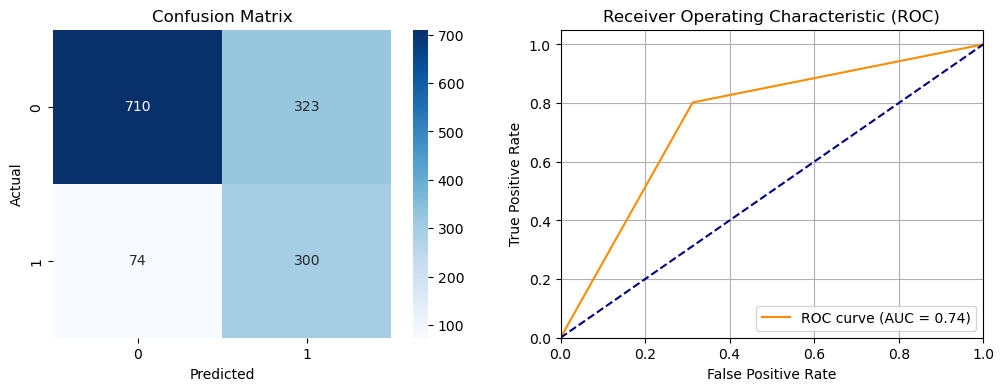

Classification Report:
              precision    recall  f1-score   support

       False       0.91      0.69      0.78      1033
        True       0.48      0.80      0.60       374

    accuracy                           0.72      1407
   macro avg       0.69      0.74      0.69      1407
weighted avg       0.79      0.72      0.73      1407



In [313]:
evaluate_model(rf_analysis['model'], X_test_sel, y_test)

## SVM

In [314]:
from sklearn.svm import SVC

In [365]:
SVC = SVC(kernel='rbf', class_weight='balanced',gamma='auto', C=1.0, random_state=42)

In [366]:
svc_analysis = bias_variance_analysis(SVC, X_train_sel, y_train, cv=5, model_name='SVM')

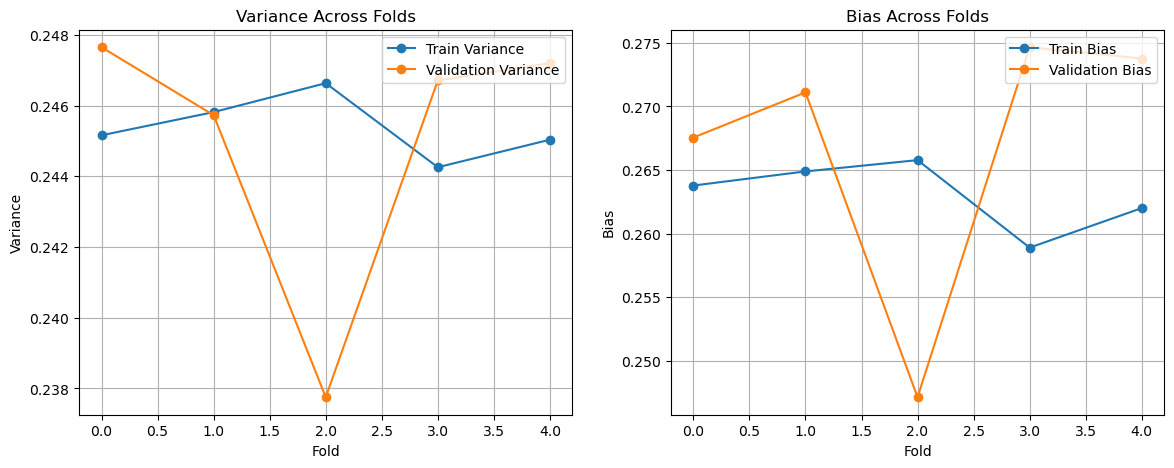

Average Train Bias: 0.2631
Average Validation Bias: 0.2668
Average Train Variance: 0.2454
Average Validation Variance: 0.2450
Average Train Score: 0.7369
Average Validation Score: 0.7332


In [367]:
plot_bias_variance_from_analysis(svc_analysis)

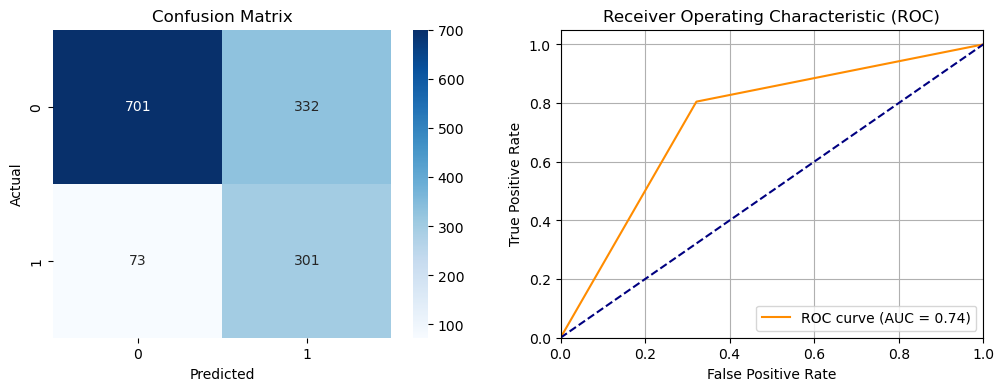

Classification Report:
              precision    recall  f1-score   support

       False       0.91      0.68      0.78      1033
        True       0.48      0.80      0.60       374

    accuracy                           0.71      1407
   macro avg       0.69      0.74      0.69      1407
weighted avg       0.79      0.71      0.73      1407



In [368]:
evaluate_model(svc_analysis['model'], X_test_sel, y_test)

## SMOTETomek

In [319]:
from imblearn.combine import SMOTETomek

In [320]:
st = SMOTETomek(random_state=42)
X_train_st, y_train_st = st.fit_resample(X_train_sel, y_train)

## RF + SMOTETomek

In [369]:
RF_ST = RandomForestClassifier(random_state=42, class_weight='balanced', ccp_alpha=0.01, oob_score=True)

In [370]:
rf_st_analysis = bias_variance_analysis(RF_ST, X_train_st, y_train_st, cv=5, model_name='SVM')

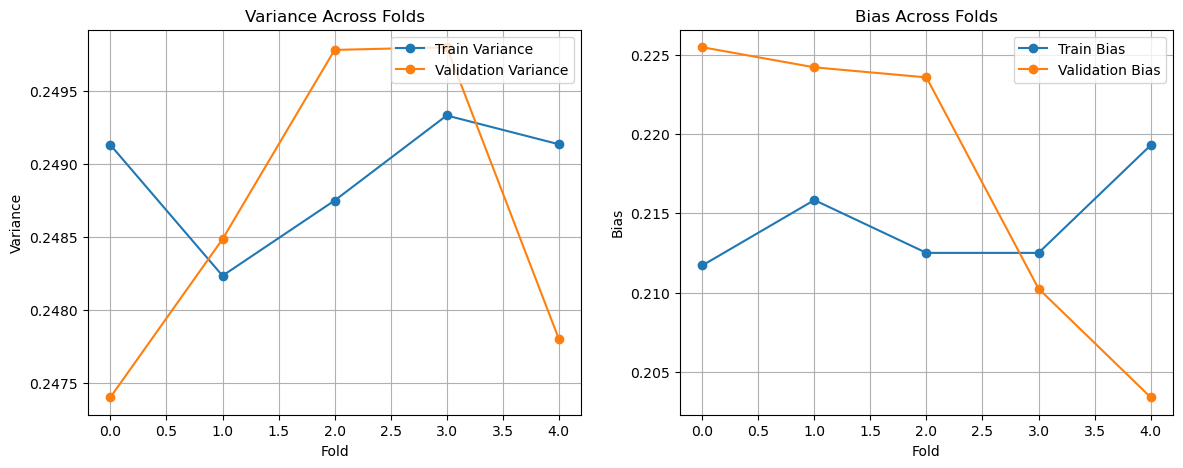

Average Train Bias: 0.2144
Average Validation Bias: 0.2174
Average Train Variance: 0.2489
Average Validation Variance: 0.2487
Average Train Score: 0.7856
Average Validation Score: 0.7826


In [371]:
plot_bias_variance_from_analysis(rf_st_analysis)

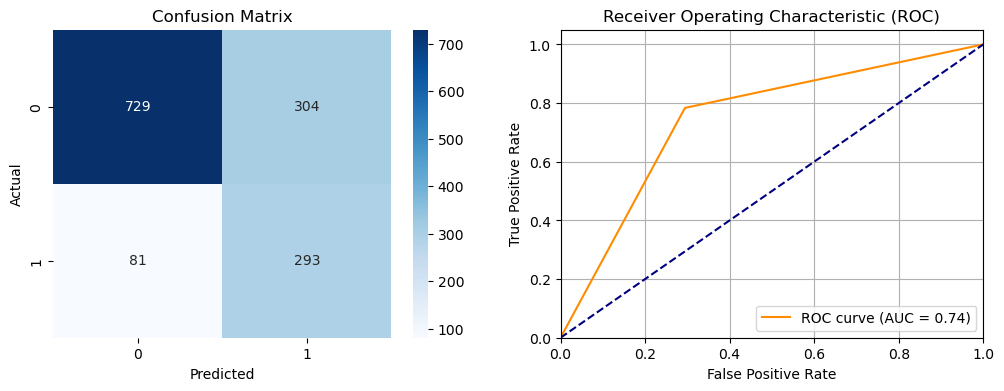

Classification Report:
              precision    recall  f1-score   support

       False       0.90      0.71      0.79      1033
        True       0.49      0.78      0.60       374

    accuracy                           0.73      1407
   macro avg       0.70      0.74      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [372]:
evaluate_model(rf_st_analysis['model'], X_test_sel, y_test)

## SVC + SMOTETomek

In [374]:
from sklearn.svm import SVC

In [375]:
SVC_ST = SVC(kernel='rbf', class_weight='balanced',gamma='auto', C=1.0, random_state=42)

In [376]:
svc_st_analysis = bias_variance_analysis(SVC_ST, X_train_st, y_train_st, cv=5, model_name='SVM')

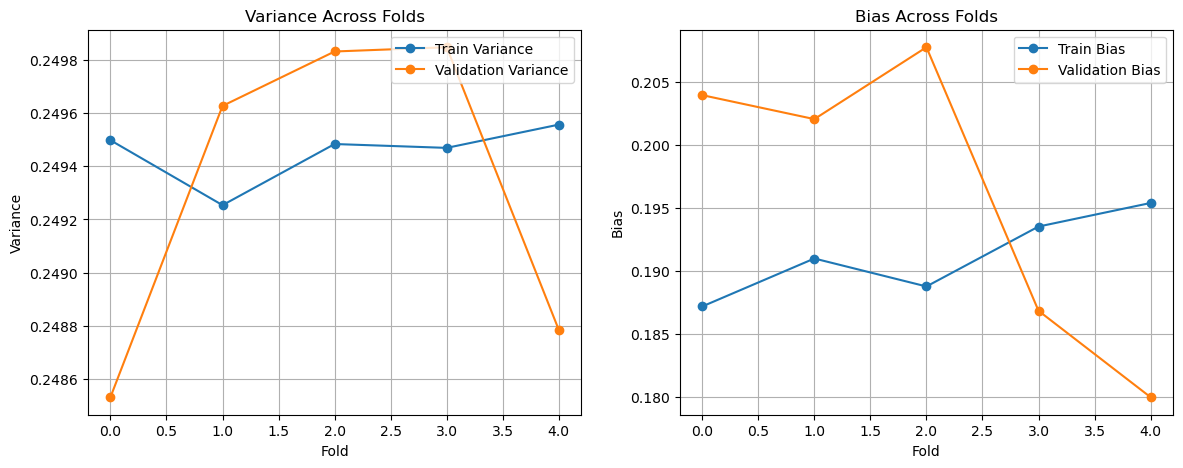

Average Train Bias: 0.1912
Average Validation Bias: 0.1961
Average Train Variance: 0.2495
Average Validation Variance: 0.2493
Average Train Score: 0.8088
Average Validation Score: 0.8039


In [377]:
plot_bias_variance_from_analysis(svc_st_analysis)

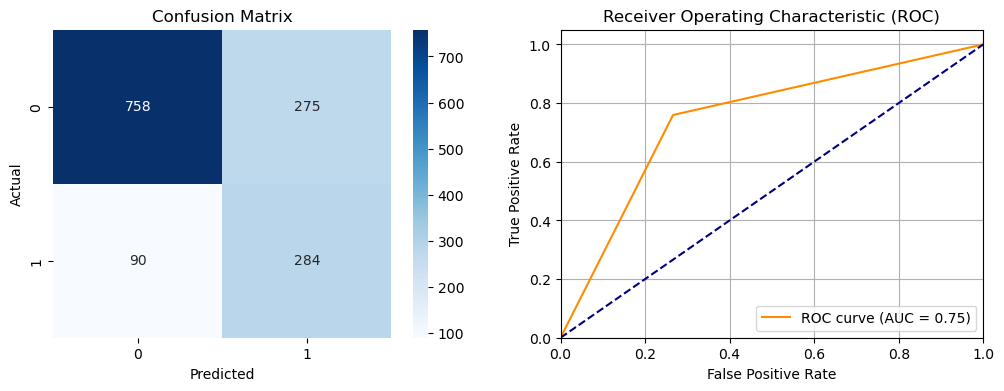

Classification Report:
              precision    recall  f1-score   support

       False       0.89      0.73      0.81      1033
        True       0.51      0.76      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.75      1407



In [378]:
evaluate_model(svc_st_analysis['model'], X_test_sel, y_test)

## RF + SMOTETomek + Bayesian Tuning

In [330]:
from skopt import BayesSearchCV

In [335]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 8],
    'min_samples_leaf': [1, 5, 9]
}

# Initialize Bayesian Optimization
rf_opt = BayesSearchCV(
    RandomForestClassifier(class_weight='balanced', ccp_alpha=0.01, oob_score=True, random_state=42),
    param_grid_rf,
    n_iter=40,
    scoring='recall',
    cv=5
)

In [336]:
rf_opt.fit(X_train_st, y_train_st)

print(f"val. score: {rf_opt.best_score_}")

val. score: 0.8239213232580898


In [337]:
best_rf_params = rf_opt.best_params_
print("Best Hyperparameters:", best_rf_params)

Best Hyperparameters: OrderedDict({'max_depth': 20, 'min_samples_leaf': 5, 'min_samples_split': 8, 'n_estimators': 200})


In [338]:
y_pred_rf_opt = rf_opt.predict(X_test_sel)

In [339]:
print("Best val score:", rf_opt.best_score_)

Best val score: 0.8239213232580898


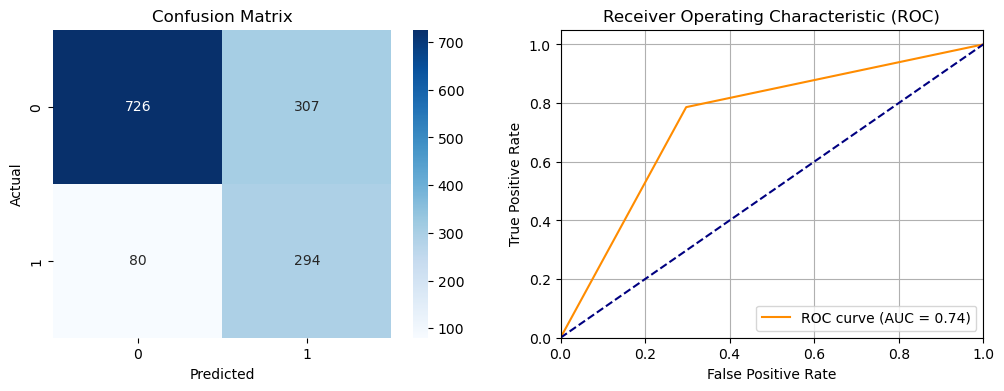

Classification Report:
              precision    recall  f1-score   support

       False       0.90      0.70      0.79      1033
        True       0.49      0.79      0.60       374

    accuracy                           0.72      1407
   macro avg       0.69      0.74      0.70      1407
weighted avg       0.79      0.72      0.74      1407



In [340]:
evaluate_model(rf_opt, X_test_sel, y_test)

## SVC + SMOTETomek + Bayesian Tuning

In [349]:
param_grid_svc = {
    'C': [0.1, 1],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'kernel': ['rbf', 'linear', 'poly']
}

# Initialize Bayesian Optimization
svc_opt = BayesSearchCV(
    SVC(class_weight='balanced', random_state=42),
    param_grid_svc,
    n_iter=15,
    scoring='recall',
    cv=5
)

C:\Users\GF63\AppData\Roaming\Python\Python312\site-packages\skopt\space\space.py:116: UserWarning: Dimension [0.1, 1] was inferred to Real(low=0.1, high=1.0, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to Categorical(categories=(0.1, 1), prior=None). See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(


In [350]:
svc_opt.fit(X_train_st, y_train_st)


C:\Users\GF63\AppData\Roaming\Python\Python312\site-packages\skopt\space\space.py:116: UserWarning: Dimension [0.1, 1] was inferred to Real(low=0.1, high=1.0, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to Categorical(categories=(0.1, 1), prior=None). See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
C:\Users\GF63\AppData\Roaming\Python\Python312\site-packages\skopt\space\space.py:116: UserWarning: Dimension [0.1, 1] was inferred to Real(low=0.1, high=1.0, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to Categorical(categories=(0.1, 1), prior=None). See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
C:\Users\GF63\AppData\Roaming\Python\Python312\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [0.1, 0.001, 'rbf'] before, using random point

BayesSearchCV(cv=5, estimator=SVC(class_weight='balanced', random_state=42),
              n_iter=15, scoring='recall',
              search_spaces={'C': [0.1, 1],
                             'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
                             'kernel': ['rbf', 'linear', 'poly']})

In [351]:
print("val. score:", svc_opt.best_score_)
print("Best Hyperparameters:", svc_opt.best_params_)


val. score: 0.8606548908247902
Best Hyperparameters: OrderedDict({'C': 0.1, 'gamma': 0.001, 'kernel': 'rbf'})


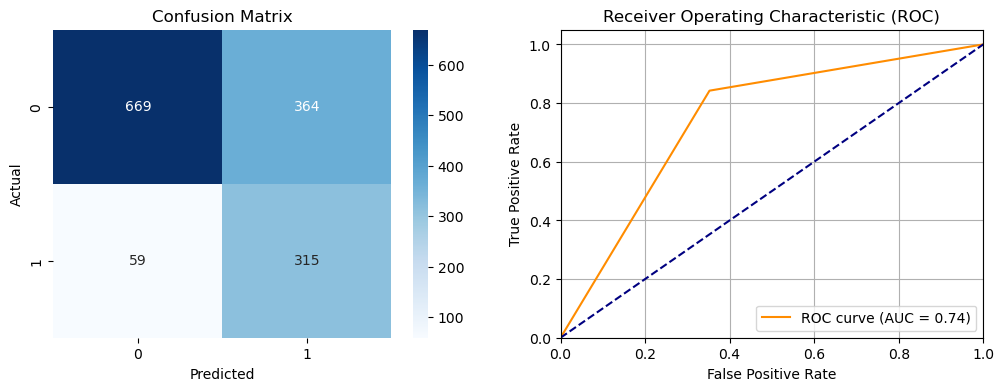

Classification Report:
              precision    recall  f1-score   support

       False       0.92      0.65      0.76      1033
        True       0.46      0.84      0.60       374

    accuracy                           0.70      1407
   macro avg       0.69      0.74      0.68      1407
weighted avg       0.80      0.70      0.72      1407



In [352]:
evaluate_model(svc_opt, X_test_sel, y_test)

## Recall

In [379]:
pd.DataFrame({
    'Ordinary' : [0.80, 0.80],
    'SMOTETomek' : [0.78, 0.76],
    'Bayesian Tuning': [0.79, 0.84],
}, index=['RF', 'SVC'])

,Ordinary,SMOTETomek,Bayesian Tuning
RF,0.8,0.78,0.79
SVC,0.8,0.76,0.84


## ROC AUC

In [380]:
pd.DataFrame({
    'Ordinary' : [0.74, 0.74],
    'SMOTETomek' : [0.74, 0.75],
    'Bayesian Tuning': [0.74, 0.74],
}, index=['RF', 'SVC'])

,Ordinary,SMOTETomek,Bayesian Tuning
RF,0.74,0.74,0.74
SVC,0.74,0.75,0.74


- Because the testing data is imbalance so we will use recall and roc-aucfor benchmark evaluation to choose the best model.
- Based on the experiment that we have done it shows that SVC+Bayesian Tuning gave the best performance with recall = **84%** and auc score = **74%**.

# Conclusion
This project explored Telco customer churn prediction by cleaning the raw dataset, performing EDA, handling imbalance, and evaluating multiple classification strategies.

Key EDA findings:
- The dataset is imbalanced: about 26.6% of customers churn while 73.4% stay.
- Numerical features show skewed distributions: churners are concentrated in lower tenure (2-29 months), higher monthly charges (56-94), and moderate total charges (134-2331).
- Categorical analysis revealed strong churn signals for month-to-month contracts, no online security, no tech support, fiber optic internet service, paperless billing, and electronic check payment.
- Correlation analysis showed a high relationship between tenure and total charges (0.89) and a moderate relationship between monthly charges and total charges (0.64), while churn-related associations were strongest with contract type and support/service features.

Modeling insights:
- Data preprocessing included encoding categorical variables, converting TotalCharges, and scaling skewed numeric features using RobustScaler.
- Imbalance handling with SMOTETomek and Bayesian hyperparameter tuning helped improve recall on the minority churn class.
- The best-performing model in this notebook was SVC with Bayesian tuning, achieving recall = 84% and ROC AUC = 74% on the test set.

Overall, the project demonstrates that careful EDA, imbalance-aware evaluation, and hyperparameter tuning are essential for building a reliable churn prediction model. Future work can focus on richer feature engineering, ensemble models, and additional sampling or cost-sensitive learning techniques.